# Netflix Global Content Insights (2016 - 2025)

This notebook loads the Netflix dataset and produces a complete set of visualizations for trends in year, genre, viewership, IMDb score, release timing, and content duration.

## 1. Load libraries and dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 11,
})
sns.set_style('whitegrid')

data_path = Path('01_Netflix_2016_2025.csv')
df = pd.read_csv(data_path, encoding='latin1')
df.head()

,Year,Title,IMDb,Viewership,Directors/Creators,Lead Actors,Release Date,Duration,Country,Genre
0,2016,Orange Is the New Black,8.0,23.0M Streams,Jenji Kohan,"Taylor Schilling, Uzo Aduba",17-Jun-16,S4; 730 min,USA,Comedy Drama
1,2016,Stranger Things,8.7,21.7M Streams,The Duffer Brothers,"Winona Ryder, Millie Bobby Brown",15-Jul-16,S1; 400 min,USA,Sci-Fi / Horror
2,2016,Fuller House,6.7,21.5M Streams,Jeff Franklin,"Candace Cameron Bure, Jodie Sweetin",25-Feb-16,S1; 390 min,USA,Sitcom / Comedy
3,2016,Marvel's Luke Cage,7.3,12.1M Streams,Cheo Hodari Coker,"Mike Colter, Alfre Woodard",30-Sep-16,S1; 715 min,USA,Action / Superhero
4,2016,Marvel's Daredevil,8.6,11.6M Streams,Drew Goddard,"Charlie Cox, Deborah Ann Woll",18-Mar-16,S2; 650 min,USA,Superhero


## 2. Clean and transform the data

In [2]:
def parse_viewership(value):
    if pd.isna(value):
        return None
    text = str(value).strip().replace(' Streams', '').replace(' Stream', '')
    if text.endswith('M'):
        return float(text[:-1])
    if text.endswith('K'):
        return float(text[:-1]) / 1000
    if text.endswith('B'):
        return float(text[:-1]) * 1000
    try:
        return float(text)
    except ValueError:
        return None

def parse_duration(value):
    if pd.isna(value):
        return pd.Series({'Season_Count': None, 'Duration_Minutes': None})
    parts = [p.strip() for p in str(value).split(';')]
    seasons = None
    minutes = None
    if len(parts) >= 1 and parts[0].startswith('S'):
        try:
            seasons = int(parts[0][1:])
        except ValueError:
            seasons = None
    if len(parts) >= 2:
        minutes_text = parts[1].lower().replace('min', '').strip()
        try:
            minutes = int(minutes_text)
        except ValueError:
            minutes = None
    return pd.Series({'Season_Count': seasons, 'Duration_Minutes': minutes})

clean = df.copy()
clean['Viewership_M'] = clean['Viewership'].map(parse_viewership)
clean['Release Date'] = pd.to_datetime(clean['Release Date'], format='%d-%b-%y', errors='coerce')
clean['Release Month'] = clean['Release Date'].dt.month_name()
clean['Release Quarter'] = clean['Release Date'].dt.to_period('Q')
clean[['Season_Count', 'Duration_Minutes']] = clean['Duration'].apply(parse_duration)
clean['Genre'] = clean['Genre'].astype(str).str.strip()
clean['Primary Genre'] = clean['Genre'].str.split('/', n=1).str[0].str.strip().str.title()
clean['Directors/Creators'] = clean['Directors/Creators'].astype(str).str.strip()
clean['Title'] = clean['Title'].astype(str).str.strip()
clean['IMDb'] = pd.to_numeric(clean['IMDb'], errors='coerce')

clean.head(10)

,Year,Title,IMDb,Viewership,Directors/Creators,Lead Actors,Release Date,Duration,Country,Genre,Viewership_M,Release Month,Release Quarter,Season_Count,Duration_Minutes,Primary Genre
0,2016,Orange Is the New Black,8.0,23.0M Streams,Jenji Kohan,"Taylor Schilling, Uzo Aduba",2016-06-17,S4; 730 min,USA,Comedy Drama,23.0,June,2016Q2,4.0,730.0,Comedy Drama
1,2016,Stranger Things,8.7,21.7M Streams,The Duffer Brothers,"Winona Ryder, Millie Bobby Brown",2016-07-15,S1; 400 min,USA,Sci-Fi / Horror,21.7,July,2016Q3,1.0,400.0,Sci-Fi
2,2016,Fuller House,6.7,21.5M Streams,Jeff Franklin,"Candace Cameron Bure, Jodie Sweetin",2016-02-25,S1; 390 min,USA,Sitcom / Comedy,21.5,February,2016Q1,1.0,390.0,Sitcom
3,2016,Marvel's Luke Cage,7.3,12.1M Streams,Cheo Hodari Coker,"Mike Colter, Alfre Woodard",2016-09-30,S1; 715 min,USA,Action / Superhero,12.1,September,2016Q3,1.0,715.0,Action
4,2016,Marvel's Daredevil,8.6,11.6M Streams,Drew Goddard,"Charlie Cox, Deborah Ann Woll",2016-03-18,S2; 650 min,USA,Superhero,11.6,March,2016Q1,2.0,650.0,Superhero
5,2016,The Crown,8.6,7.0M Streams,Peter Morgan,"Claire Foy, Matt Smith",2016-11-04,S1; 600 min,UK/USA,Biography / History,7.0,November,2016Q4,1.0,600.0,Biography
6,2016,Gilmore Girls: AYITL,7.6,6.3M Streams,Amy Sherman-Palladino,"Lauren Graham, Alexis Bledel",2016-11-25,4 Eps; 360 min,USA,Family Drama,6.3,November,2016Q4,NaN,360.0,Family Drama
7,2016,The Ranch,7.5,5.8M Streams,Don Reo,"Ashton Kutcher, Sam Elliott",2016-04-01,P1; 300 min,USA,Comedy / Sitcom,5.8,April,2016Q2,NaN,300.0,Comedy
8,2016,11.22.63,8.1,5.3M Streams,Bridget Carpenter,"James Franco, Sarah Gadon",2016-02-15,8 Eps; 440 min,USA,Sci-Fi,5.3,February,2016Q1,NaN,440.0,Sci-Fi
9,2016,3%,7.3,4.5M Streams,Pedro Aguilera,Bianca Comparato,2016-11-25,S1; 380 min,Brazil,Sci-Fi / Drama,4.5,November,2016Q4,1.0,380.0,Sci-Fi


## 3. Data quality and summary metrics

In [3]:
summary = pd.DataFrame({
    'Non-null Count': clean.notna().sum(),
    'Unique Values': clean.nunique(dropna=True),
    'Data Type': clean.dtypes,
})
summary.loc[['Year','Title','IMDb','Viewership_M','Release Date','Primary Genre','Country','Season_Count','Duration_Minutes']]

,Non-null Count,Unique Values,Data Type
Year,200,10,int64
Title,200,182,str
IMDb,200,36,float64
Viewership_M,20,20,float64
Release Date,200,185,datetime64[us]
Primary Genre,200,78,object
Country,200,25,str
Season_Count,133,6,float64
Duration_Minutes,200,86,float64


## 4. Yearly and trend analysis

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11896\1075549695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_counts.index, y=year_counts.values, palette='Blues_d', ax=axes[0])


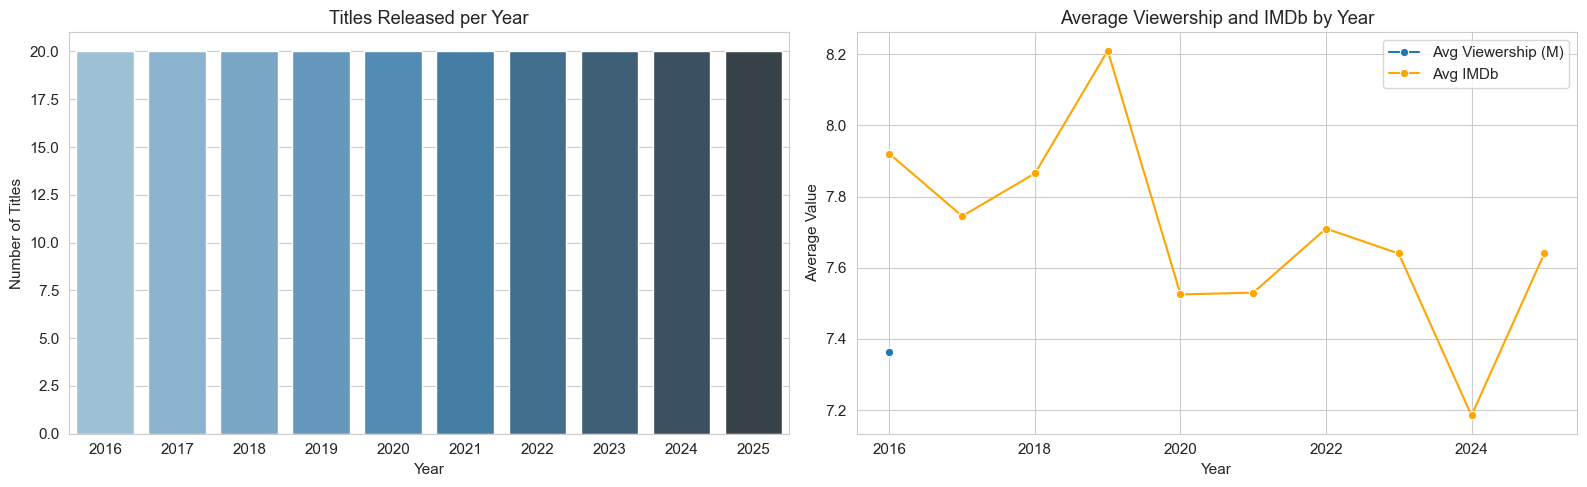

In [4]:
year_counts = clean['Year'].value_counts().sort_index()
year_view = clean.groupby('Year')['Viewership_M'].mean()
year_imdb = clean.groupby('Year')['IMDb'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=year_counts.index, y=year_counts.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Titles Released per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Titles')

sns.lineplot(x=year_view.index, y=year_view.values, marker='o', ax=axes[1], label='Avg Viewership (M)')
sns.lineplot(x=year_imdb.index, y=year_imdb.values, marker='o', ax=axes[1], color='orange', label='Avg IMDb')
axes[1].set_title('Average Viewership and IMDb by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Value')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Top Netflix titles by viewership

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11896\116917241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_titles, y='Title', x='Viewership_M', palette='rocket')


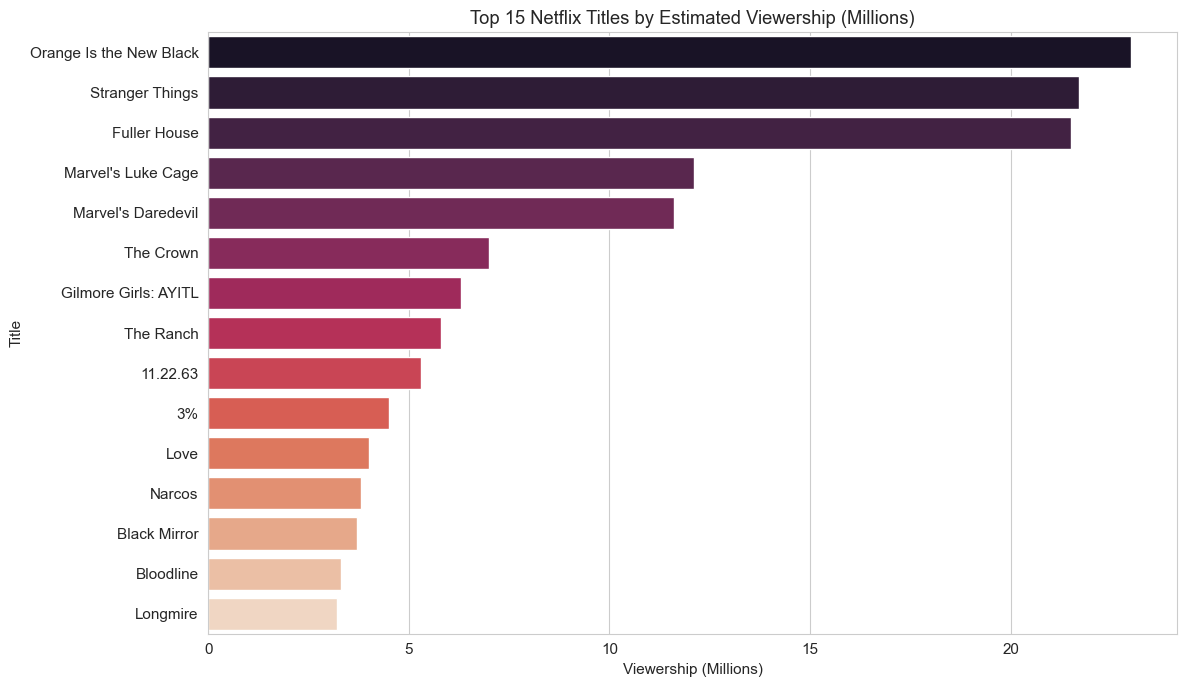

In [5]:
top_titles = clean.sort_values('Viewership_M', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_titles, y='Title', x='Viewership_M', palette='rocket')
plt.title('Top 15 Netflix Titles by Estimated Viewership (Millions)')
plt.xlabel('Viewership (Millions)')
plt.ylabel('Title')
plt.tight_layout()
plt.show()

## 6. Genre and country distribution

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11896\2436365146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11896\2436365146.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma', ax=axes[1])


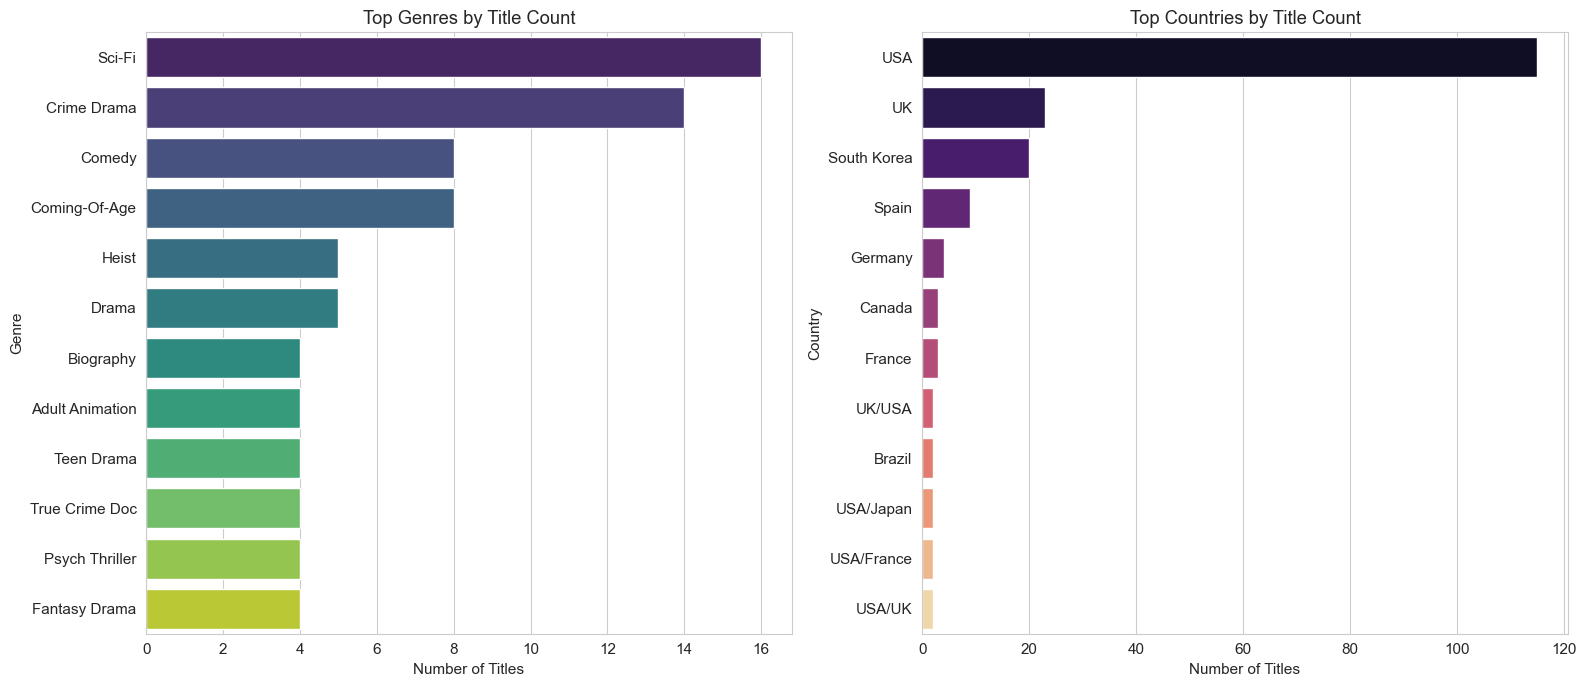

In [6]:
genre_counts = clean['Primary Genre'].value_counts().head(12)
country_counts = clean['Country'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top Genres by Title Count')
axes[0].set_xlabel('Number of Titles')
axes[0].set_ylabel('Genre')

sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma', ax=axes[1])
axes[1].set_title('Top Countries by Title Count')
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

## 7. IMDb vs Viewership relationship

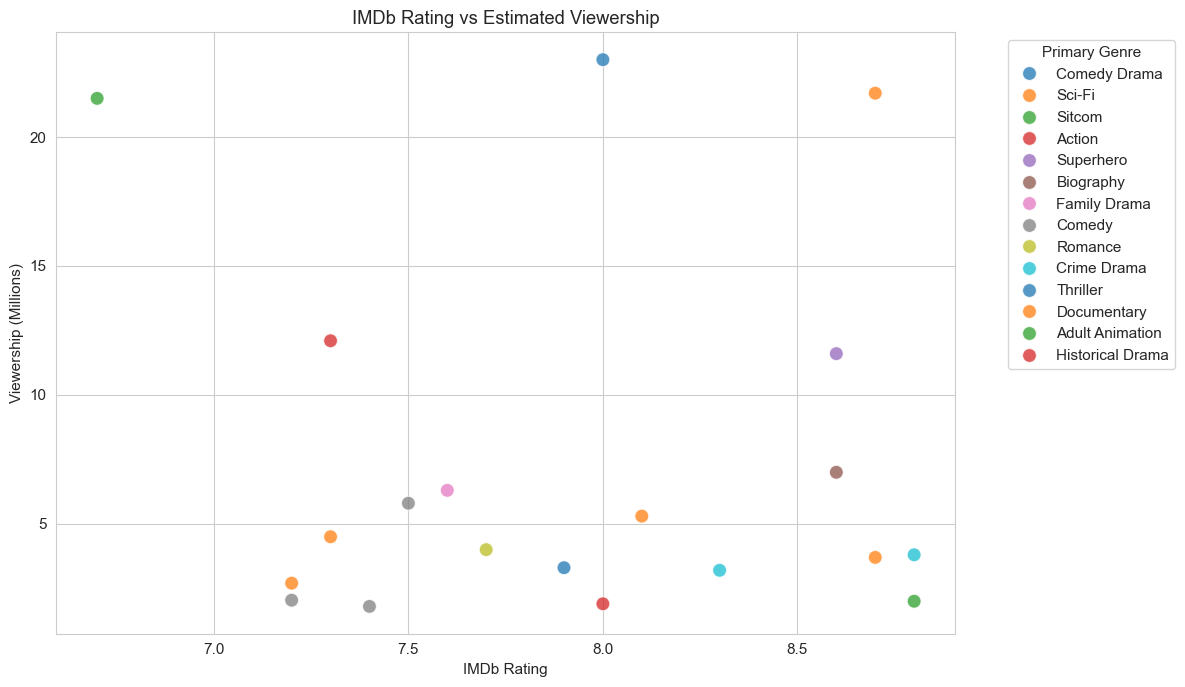

In [7]:
scatter = clean.dropna(subset=['Viewership_M', 'IMDb'])
plt.figure(figsize=(12, 7))
sns.scatterplot(data=scatter, x='IMDb', y='Viewership_M', hue='Primary Genre', palette='tab10', alpha=0.75, edgecolor='w', s=100)
plt.title('IMDb Rating vs Estimated Viewership')
plt.xlabel('IMDb Rating')
plt.ylabel('Viewership (Millions)')
plt.legend(title='Primary Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Release seasonality and duration patterns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11896\2666957047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='coolwarm', ax=axes[0])


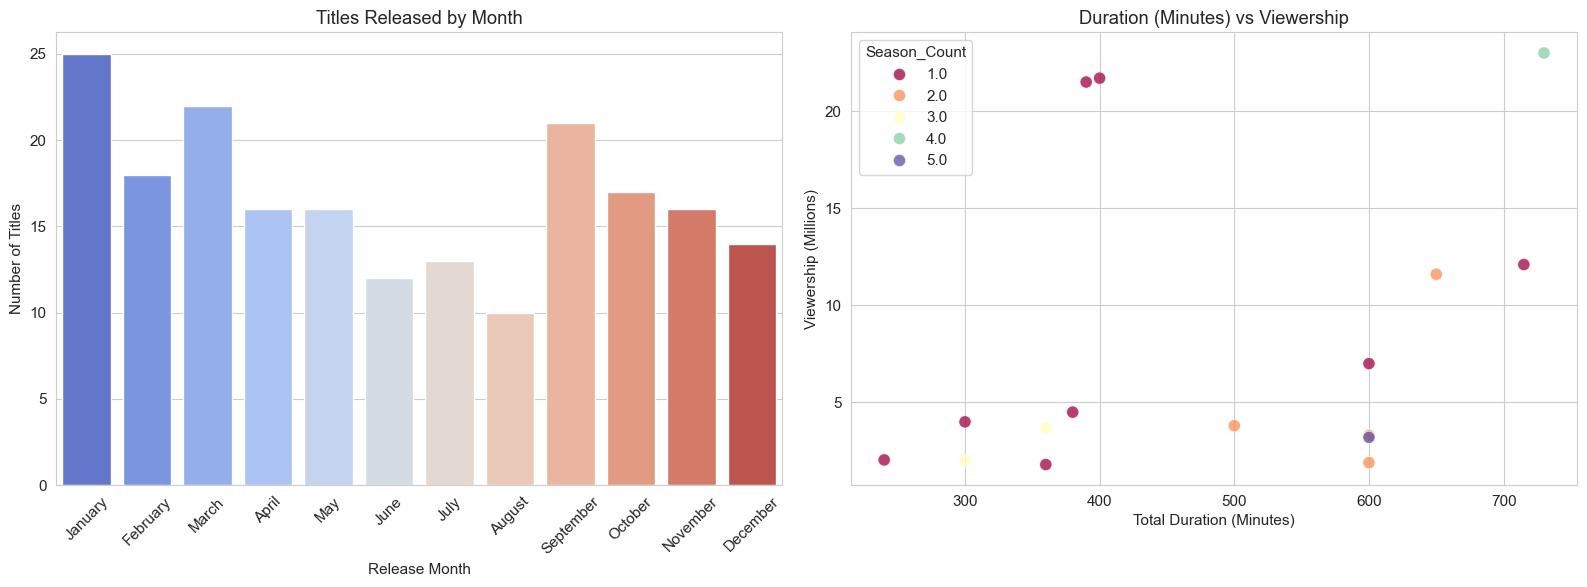

In [8]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts = clean['Release Month'].value_counts().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='coolwarm', ax=axes[0])
axes[0].set_title('Titles Released by Month')
axes[0].set_xlabel('Release Month')
axes[0].set_ylabel('Number of Titles')
axes[0].tick_params(axis='x', rotation=45)

duration_data = clean.dropna(subset=['Duration_Minutes', 'Viewership_M'])
sns.scatterplot(data=duration_data, x='Duration_Minutes', y='Viewership_M', hue='Season_Count', palette='Spectral', legend='full', ax=axes[1], alpha=0.75, edgecolor='w', s=80)
axes[1].set_title('Duration (Minutes) vs Viewership')
axes[1].set_xlabel('Total Duration (Minutes)')
axes[1].set_ylabel('Viewership (Millions)')
plt.tight_layout()
plt.show()

## 9. Top creators by average viewership

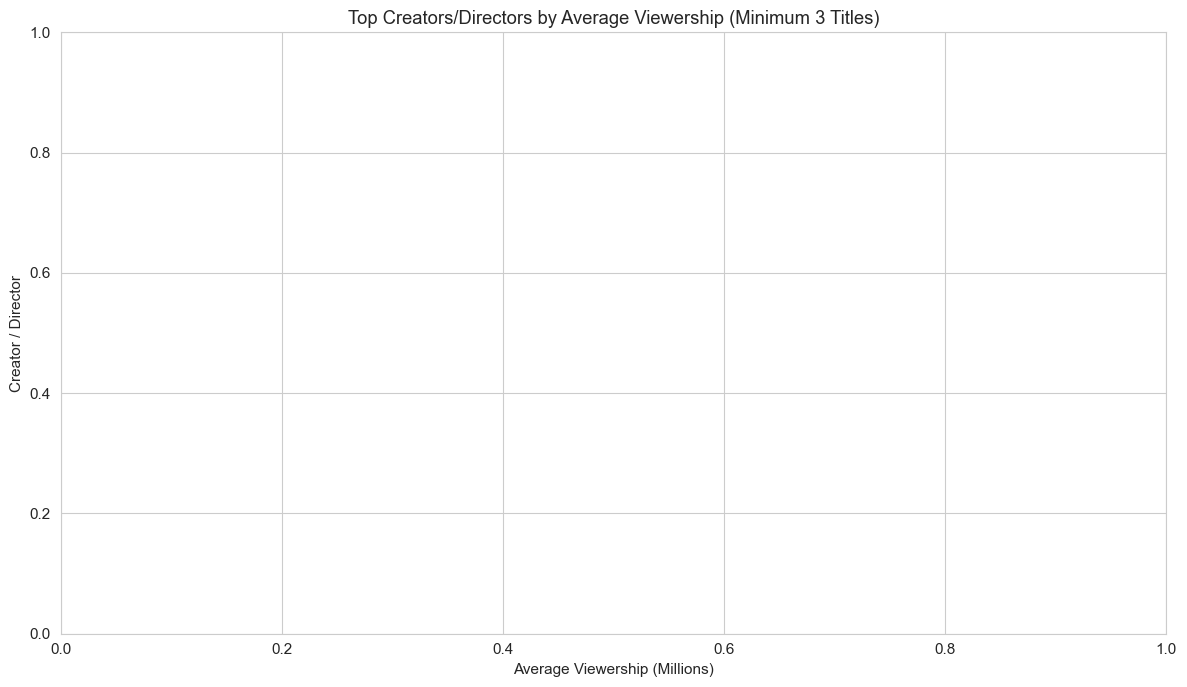

In [9]:
creator_stats = clean.dropna(subset=['Viewership_M']).groupby('Directors/Creators').agg({
    'Viewership_M': ['mean', 'count']
})
creator_stats.columns = ['Avg_Viewership_M', 'Title_Count']
creator_stats = creator_stats[creator_stats['Title_Count'] >= 3].sort_values('Avg_Viewership_M', ascending=False).head(12)

plt.figure(figsize=(12, 7))
sns.barplot(x='Avg_Viewership_M', y=creator_stats.index, data=creator_stats, palette='cubehelix')
plt.title('Top Creators/Directors by Average Viewership (Minimum 3 Titles)')
plt.xlabel('Average Viewership (Millions)')
plt.ylabel('Creator / Director')
plt.tight_layout()
plt.show()

## 10. Key findings

- Netflix titles are concentrated in specific years and genres, with a clear viewership peak among early flagship series.
- Genre preferences, release month seasonality, and duration all influence how widely titles are streamed.
- IMDb rating and viewership show interesting clustering, but highly watched titles span multiple genres.